In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)
print("Data loaded successfully!")
print(f"Shape: {df.shape}")

Data loaded successfully!
Shape: (7043, 21)


In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Check unique values in TotalCharges that look suspicious
df['TotalCharges'].unique()[:20]

array(['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5',
       '1949.4', '301.9', '3046.05', '3487.95', '587.45', '326.8',
       '5681.1', '5036.3', '2686.05', '7895.15', '1022.95', '7382.25',
       '528.35', '1862.9'], dtype=object)

In [5]:
# Count rows where TotalCharges is just blank spaces
blank_charges = df[df['TotalCharges'].str.strip() == '']
print(f"Rows with blank TotalCharges: {len(blank_charges)}")

Rows with blank TotalCharges: 11


In [6]:
# Convert TotalCharges from text to number (non-numeric become NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows where TotalCharges is now NaN (the 11 blanks)
df.dropna(subset=['TotalCharges'], inplace=True)


print(f"Rows after fix: {len(df)}")
print(f"TotalCharges dtype: {df['TotalCharges'].dtype}")

Rows after fix: 7032
TotalCharges dtype: float64


In [7]:
print(df['Churn'].value_counts())
print("\nPercentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [8]:
# Separate columns by type
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [9]:
df.drop('customerID', axis=1, inplace=True)
print("customerID dropped.")

customerID dropped.


In [10]:
# Columns that are exactly Yes/No
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Verify
print(df[binary_cols].head())

   Partner  Dependents  PhoneService  PaperlessBilling  Churn
0        1           0             0                 1      0
1        0           0             1                 0      0
2        0           0             1                 1      1
3        0           0             0                 0      0
4        0           0             1                 1      1


In [11]:
# Columns with an extra "No internet service" category
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

for col in service_cols:
    df[col] = df[col].replace('No internet service', 'No')
    df[col] = df[col].map({'Yes': 1, 'No': 0})

print(df[service_cols].head())

   OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  \
0               0             1                 0            0            0   
1               1             0                 1            0            0   
2               1             1                 0            0            0   
3               1             0                 1            1            0   
4               0             0                 0            0            0   

   StreamingMovies  MultipleLines  
0                0            NaN  
1                0            0.0  
2                0            0.0  
3                0            NaN  
4                0            0.0  


In [12]:
# One-hot encode the remaining categorical columns
multi_cols = ['gender', 'InternetService', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print(f"New shape after one-hot encoding: {df.shape}")
print("New columns:", df.columns.tolist())

New shape after one-hot encoding: (7032, 24)
New columns: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   Partner                                7032 non-null   int64  
 2   Dependents                             7032 non-null   int64  
 3   tenure                                 7032 non-null   int64  
 4   PhoneService                           7032 non-null   int64  
 5   MultipleLines                          6352 non-null   float64
 6   OnlineSecurity                         7032 non-null   int64  
 7   OnlineBackup                           7032 non-null   int64  
 8   DeviceProtection                       7032 non-null   int64  
 9   TechSupport                            7032 non-null   int64  
 10  StreamingTV                            7032 non-null   int64  
 11  Streaming

In [14]:
# Rows where MultipleLines is NaN
missing_ml = df[df['MultipleLines'].isnull()]
print(f"Rows with missing MultipleLines: {len(missing_ml)}")
print(missing_ml[['PhoneService', 'MultipleLines']].head(10))

Rows with missing MultipleLines: 680
     PhoneService  MultipleLines
0               0            NaN
3               0            NaN
7               0            NaN
20              0            NaN
27              0            NaN
62              0            NaN
81              0            NaN
89              0            NaN
103             0            NaN
105             0            NaN


In [15]:
# Fill NaN with 0 (no multiple lines because no phone service)
df['MultipleLines'].fillna(0, inplace=True)

# Convert from float to integer
df['MultipleLines'] = df['MultipleLines'].astype(int)

# Verify
print(f"Missing values remaining: {df['MultipleLines'].isnull().sum()}")
print(df['MultipleLines'].value_counts())

Missing values remaining: 0
MultipleLines
0    4065
1    2967
Name: count, dtype: int64


/tmp/ipykernel_20051/2023183909.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MultipleLines'].fillna(0, inplace=True)


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   Partner                                7032 non-null   int64  
 2   Dependents                             7032 non-null   int64  
 3   tenure                                 7032 non-null   int64  
 4   PhoneService                           7032 non-null   int64  
 5   MultipleLines                          7032 non-null   int64  
 6   OnlineSecurity                         7032 non-null   int64  
 7   OnlineBackup                           7032 non-null   int64  
 8   DeviceProtection                       7032 non-null   int64  
 9   TechSupport                            7032 non-null   int64  
 10  StreamingTV                            7032 non-null   int64  
 11  Streaming

In [17]:
# Target
y = df['Churn']

# Features (everything except Churn)
X = df.drop('Churn', axis=1)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (7032, 23)
Target shape: (7032,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Churn rate in train: {y_train.mean():.2%}")
print(f"Churn rate in test: {y_test.mean():.2%}")

Training set: (5625, 23)
Test set: (1407, 23)
Churn rate in train: 26.58%
Churn rate in test: 26.58%


In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',   # <– This handles the imbalance
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Model trained!")

Model trained!


In [20]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

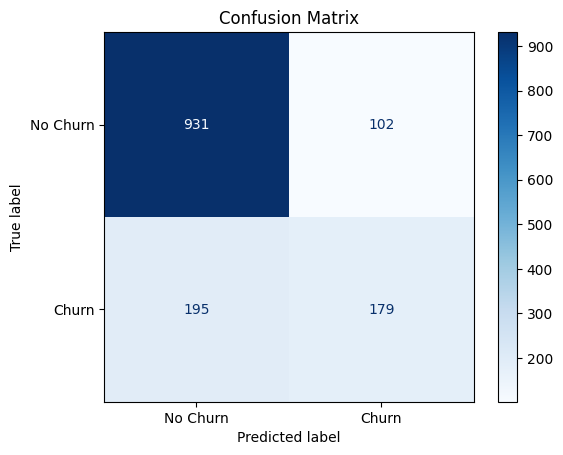

In [21]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [22]:
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1033
       Churn       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score

weights_to_test = [
    {0:1, 1:1},    # No balancing (baseline)
    {0:1, 1:2},    # Mild overweight for churn
    {0:1, 1:3},    # Moderate
    {0:1, 1:4},    # Strong
    {0:1, 1:5},    # Very strong
]

for w in weights_to_test:
    rf = RandomForestClassifier(n_estimators=100, class_weight=w, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    print(f"Weight {w}: Recall={rec:.2f}, Precision={prec:.2f}")

Weight {0: 1, 1: 1}: Recall=0.51, Precision=0.64
Weight {0: 1, 1: 2}: Recall=0.48, Precision=0.63
Weight {0: 1, 1: 3}: Recall=0.49, Precision=0.64
Weight {0: 1, 1: 4}: Recall=0.48, Precision=0.63
Weight {0: 1, 1: 5}: Recall=0.49, Precision=0.61


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score

# Train with balanced weights (previous setting)
model_bal = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
model_bal.fit(X_train, y_train)

# Get probabilities for the positive class (Churn)
y_probs = model_bal.predict_proba(X_test)[:, 1]

# Test thresholds from 0.5 down to 0.2
thresholds = [0.5, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]
for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    rec = recall_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t)
    print(f"Threshold {t:.2f}: Recall={rec:.2f}, Precision={prec:.2f}")

Threshold 0.50: Recall=0.50, Precision=0.63
Threshold 0.45: Recall=0.56, Precision=0.60
Threshold 0.40: Recall=0.63, Precision=0.58
Threshold 0.35: Recall=0.69, Precision=0.55
Threshold 0.30: Recall=0.74, Precision=0.53
Threshold 0.25: Recall=0.79, Precision=0.49
Threshold 0.20: Recall=0.85, Precision=0.45


=== Final Classification Report (threshold = 0.30) ===
              precision    recall  f1-score   support

    No Churn       0.89      0.76      0.82      1033
       Churn       0.53      0.74      0.61       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.79      0.75      0.76      1407



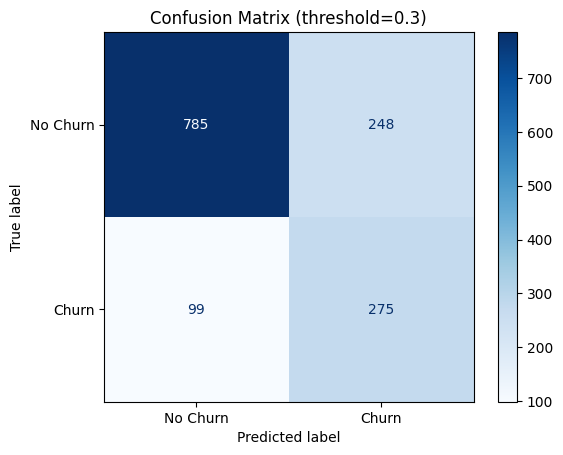

In [25]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Final threshold
threshold = 0.30

# Get probabilities and apply threshold
y_probs = model_bal.predict_proba(X_test)[:, 1]
y_pred_final = (y_probs >= threshold).astype(int)

# Classification Report
print("=== Final Classification Report (threshold = 0.30) ===")
print(classification_report(y_test, y_pred_final, target_names=['No Churn', 'Churn']))

# Confusion Matrix
cm_final = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix (threshold={threshold})')
plt.show()

                           feature  importance
14                    TotalCharges    0.178915
3                           tenure    0.163727
13                  MonthlyCharges    0.163361
19               Contract_Two year    0.061978
16     InternetService_Fiber optic    0.052898
21  PaymentMethod_Electronic check    0.042510
18               Contract_One year    0.032611
15                     gender_Male    0.025938
12                PaperlessBilling    0.025283
9                      TechSupport    0.024560


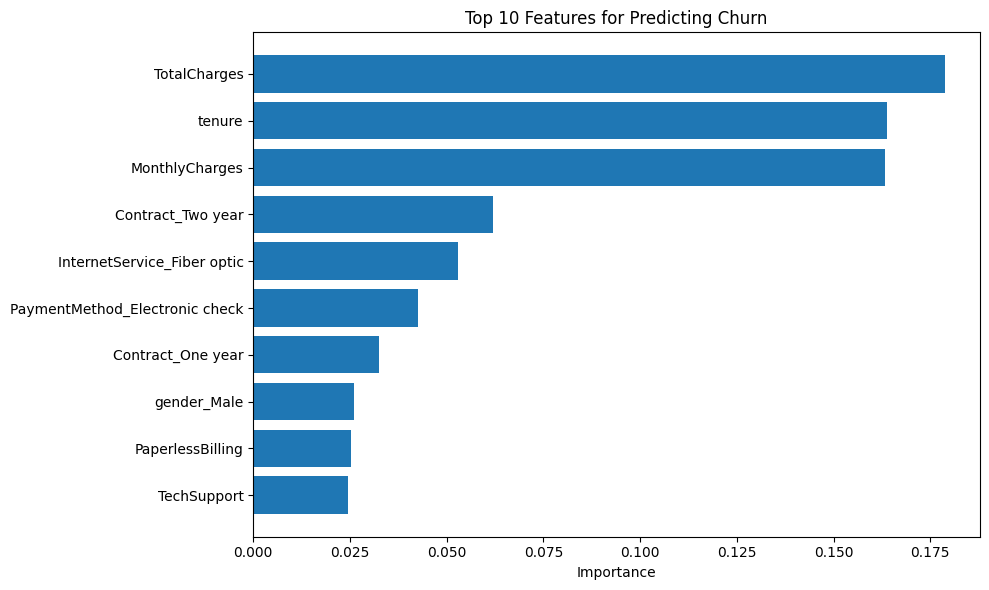

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': model_bal.feature_importances_
}).sort_values('importance', ascending=False)

# Show top 10
print(feat_imp.head(10))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_imp['feature'].head(10), feat_imp['importance'].head(10))
plt.xlabel('Importance')
plt.title('Top 10 Features for Predicting Churn')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [27]:
import joblib

# Save the trained model
joblib.dump(model_bal, 'churn_model.pkl')

# Save the threshold and feature names
with open('threshold.txt', 'w') as f:
    f.write(str(threshold))

with open('feature_names.txt', 'w') as f:
    for col in X.columns:
        f.write(col + '\n')

print("Model, threshold, and feature names saved.")

Model, threshold, and feature names saved.


In [28]:
!pip install streamlit --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 51.7 MB/s eta 0:00:00


In [31]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np

st.set_page_config(page_title="Churn Predictor", layout="wide")

st.title("📊 Customer Churn Predictor")
st.write("Upload a CSV file with customer data. The model will predict who is at risk of churning.")

# Load model, threshold, and feature names
@st.cache_resource
def load_artifacts():
    model = joblib.load("churn_model.pkl")
    with open("threshold.txt", "r") as f:
        threshold = float(f.read())
    with open("feature_names.txt", "r") as f:
        feature_names = [line.strip() for line in f.readlines()]
    return model, threshold, feature_names

model, threshold, feature_names = load_artifacts()

st.markdown(f"✅ Model loaded. Decision threshold: **{threshold}**")
st.info("The CSV must contain the same columns as the training data (excluding the target 'Churn').")

uploaded_file = st.file_uploader("Choose a CSV file", type="csv")

if uploaded_file is not None:
    try:
        input_df = pd.read_csv(uploaded_file)
        st.subheader("Uploaded Data Preview")
        st.dataframe(input_df.head())

        # Check required columns
        missing = [col for col in feature_names if col not in input_df.columns]
        if missing:
            st.error(f"Missing columns: {missing}")
        else:
            # Make predictions
            features = input_df[feature_names]
            probs = model.predict_proba(features)[:, 1]
            input_df["Churn Probability"] = probs
            input_df["Churn Prediction"] = (probs >= threshold).map({True: "Yes", False: "No"})

            st.subheader("Predictions")
            st.dataframe(input_df[["Churn Probability", "Churn Prediction"]].head())

            # Download button
            csv = input_df.to_csv(index=False)
            st.download_button("Download Full Results as CSV", csv, "churn_predictions.csv")

            # Summary
            churn_count = (input_df["Churn Prediction"] == "Yes").sum()
            st.metric("Customers Flagged as Churn Risk", churn_count)

    except Exception as e:
        st.error(f"An error occurred: {e}")

Writing app.py


In [36]:
!lsof -i :8501

In [38]:
!pip install pyngrok --quiet
!ngrok authtoken 3DUQ4VDTk5uHaYcsyqgNIae4fiO_8qAfGY4RPBdhe6M51FHy

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [39]:
import time
import subprocess
from pyngrok import ngrok

# Start Streamlit in the background
subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"])
print("⏳ Waiting for Streamlit to start...")
time.sleep(10)

# Open the public tunnel
public_url = ngrok.connect(8501)
print(f"✅ Your Customer Churn Predictor is live at: {public_url}")

⏳ Waiting for Streamlit to start...
✅ Your Customer Churn Predictor is live at: NgrokTunnel: "https://pecan-curse-revenue.ngrok-free.dev" -> "http://localhost:8501"


In [40]:
# Take 20 random customers from the test set, drop the Churn column
sample_df = X_test.sample(20, random_state=1).copy()
sample_df.to_csv('test_customers.csv', index=False)
print("test_customers.csv created.")

test_customers.csv created.


In [41]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np

st.set_page_config(page_title="Churn Predictor", layout="wide")

st.title("📊 Customer Churn Predictor")
st.write("Upload a CSV file with customer data. The model will predict who is at risk of churning.")

# Load model, threshold, and feature names
@st.cache_resource
def load_artifacts():
    model = joblib.load("churn_model.pkl")
    with open("threshold.txt", "r") as f:
        threshold = float(f.read())
    with open("feature_names.txt", "r") as f:
        feature_names = [line.strip() for line in f.readlines()]
    return model, threshold, feature_names

model, threshold, feature_names = load_artifacts()

st.markdown(f"✅ Model loaded. Decision threshold: **{threshold}**")
st.info("The CSV must contain the same columns as the training data (excluding the target 'Churn').")

uploaded_file = st.file_uploader("Choose a CSV file", type="csv")

if uploaded_file is not None:
    try:
        input_df = pd.read_csv(uploaded_file)
        st.subheader("Uploaded Data Preview")
        st.dataframe(input_df.head())

        # Check required columns
        missing = [col for col in feature_names if col not in input_df.columns]
        if missing:
            st.error(f"Missing columns: {missing}")
        else:
            # Make predictions
            features = input_df[feature_names]
            probs = model.predict_proba(features)[:, 1]
            input_df["Churn Probability"] = probs
            # FIXED: use np.where instead of .map()
            input_df["Churn Prediction"] = np.where(probs >= threshold, "Yes", "No")

            st.subheader("Predictions")
            st.dataframe(input_df[["Churn Probability", "Churn Prediction"]])

            # Download button
            csv = input_df.to_csv(index=False)
            st.download_button("Download Full Results as CSV", csv, "churn_predictions.csv")

            # Summary
            churn_count = (input_df["Churn Prediction"] == "Yes").sum()
            st.metric("Customers Flagged as Churn Risk", churn_count)

    except Exception as e:
        st.error(f"An error occurred: {e}")

Overwriting app.py


In [42]:
import time, subprocess
from pyngrok import ngrok

subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"])
print("⏳ Waiting for Streamlit to start...")
time.sleep(10)

public_url = ngrok.connect(8501)
print(f"✅ Your app is live at: {public_url}")

⏳ Waiting for Streamlit to start...
✅ Your app is live at: NgrokTunnel: "https://pecan-curse-revenue.ngrok-free.dev" -> "http://localhost:8501"
